#  **Handling Mixed Variables & Date-Time Features**
##  Overview

In this notebook, we explore feature engineering techniques for:

- Handling mixed variables
- Extracting numerical and categorical information
- Working with DateTime data
- Extracting useful date features
- Extracting useful time features
- Calculating date and time differences

**Dataset:** Titanic, Orders

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/titanic.csv')

In [ ]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


### **Inspect Mixed Variable**
The `number` column contains both text and numerical values. We'll separate them into different features.

In [ ]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

In [ ]:
# extract numerical part
df['number_numerical'] = pd.to_numeric(df["number"],errors='coerce',downcast='integer')

In [ ]:
# extract categorical part
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)

In [ ]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [ ]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [ ]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

## **Handling Cabin Feature**
The Cabin column contains an alphabetic deck identifier followed by a cabin number.

In [ ]:
df['cabin_num'] = df['Cabin'].str.extract(r'(\d+)')  # Extract numeric part
df['cabin_cat'] = df['Cabin'].str[0]                 # Extract first letter

In [ ]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

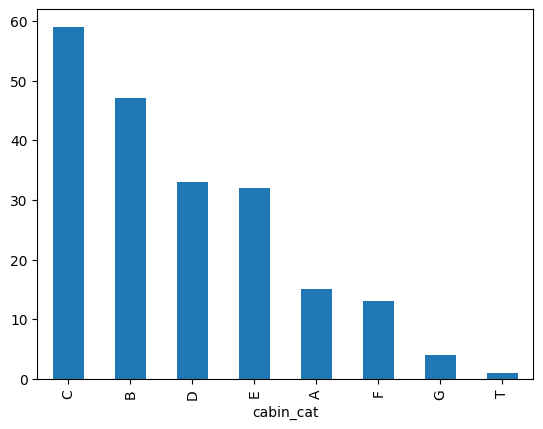

In [ ]:
df['cabin_cat'].value_counts().plot(kind='bar')

## **Handling Ticket Feature**
We'll separate the ticket number from its prefix to create useful features.

In [ ]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce',
                                   downcast='integer')

# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])

df.head(20)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
5,NaN,330877,2,0,2.0,NaN,NaN,NaN,330877.0,NaN
6,E46,17463,2,0,2.0,NaN,46,E,17463.0,NaN
7,NaN,349909,5,0,5.0,NaN,NaN,NaN,349909.0,NaN
8,NaN,347742,1,1,1.0,NaN,NaN,NaN,347742.0,NaN
9,NaN,237736,A,1,NaN,A,NaN,NaN,237736.0,NaN


# **Handling Date And Time**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
date = pd.read_csv('orders.csv')
time = pd.read_csv('messages.csv')

In [ ]:
date.head()

,date,product_id,city_id,orders
0,2019-12-10,5628,25,3
1,2018-08-15,3646,14,157
2,2018-10-23,1859,25,1
3,2019-08-17,7292,25,1
4,2019-01-06,4344,25,3


In [ ]:
time.head()

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше


### Convert Columns to DateTime
Before extracting date-related features, we convert the column into pandas DateTime format.

In [ ]:
# Converting to datetime datatype
date['date'] = pd.to_datetime(date['date'])

In [ ]:
date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1000 non-null   datetime64[ns]
 1   product_id  1000 non-null   int64         
 2   city_id     1000 non-null   int64         
 3   orders      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 31.4 KB


**1. Extract year**

In [ ]:
date['date_year'] = date['date'].dt.year

date.sample(5)

,date,product_id,city_id,orders,date_year
939,2018-08-07,5278,13,1,2018
278,2019-06-08,5024,21,4,2019
114,2019-11-28,6534,14,2,2019
449,2019-03-24,4523,13,1,2019
995,2018-10-08,255,13,1,2018


 **2. Extract Month**

In [ ]:
date['date_month_no'] = date['date'].dt.month

date.head()

,date,product_id,city_id,orders,date_year,date_month_no
0,2019-12-10,5628,25,3,2019,12
1,2018-08-15,3646,14,157,2018,8
2,2018-10-23,1859,25,1,2018,10
3,2019-08-17,7292,25,1,2019,8
4,2019-01-06,4344,25,3,2019,1


In [ ]:
date['date_month_name'] = date['date'].dt.month_name()

date.head()

,date,product_id,city_id,orders,date_year,date_month_no,date_month_name
0,2019-12-10,5628,25,3,2019,12,December
1,2018-08-15,3646,14,157,2018,8,August
2,2018-10-23,1859,25,1,2018,10,October
3,2019-08-17,7292,25,1,2019,8,August
4,2019-01-06,4344,25,3,2019,1,January


**3.Extract Days**

In [ ]:
date['date_day'] = date['date'].dt.day

date.head()

,date,product_id,city_id,orders,date_year,date_month_no,date_month_name,date_day
0,2019-12-10,5628,25,3,2019,12,December,10
1,2018-08-15,3646,14,157,2018,8,August,15
2,2018-10-23,1859,25,1,2018,10,October,23
3,2019-08-17,7292,25,1,2019,8,August,17
4,2019-01-06,4344,25,3,2019,1,January,6


In [ ]:
# day of week
date['date_dow'] = date['date'].dt.dayofweek

date.head()

,date,product_id,city_id,orders,date_year,date_month_no,date_month_name,date_day,date_dow
0,2019-12-10,5628,25,3,2019,12,December,10,1
1,2018-08-15,3646,14,157,2018,8,August,15,2
2,2018-10-23,1859,25,1,2018,10,October,23,1
3,2019-08-17,7292,25,1,2019,8,August,17,5
4,2019-01-06,4344,25,3,2019,1,January,6,6


In [ ]:
# day of week - name
date['date_dow_name'] = date['date'].dt.day_name()
date.drop(columns=['product_id','city_id','orders']).head()


,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name
0,2019-12-10,2019,12,December,10,1,Tuesday
1,2018-08-15,2018,8,August,15,2,Wednesday
2,2018-10-23,2018,10,October,23,1,Tuesday
3,2019-08-17,2019,8,August,17,5,Saturday
4,2019-01-06,2019,1,January,6,6,Sunday


In [ ]:
# is weekend?
date['date_is_weekend'] = np.where(date['date_dow_name'].isin(['Sunday', 'Saturday']), 1,0)
date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend
0,2019-12-10,2019,12,December,10,1,Tuesday,0
1,2018-08-15,2018,8,August,15,2,Wednesday,0
2,2018-10-23,2018,10,October,23,1,Tuesday,0
3,2019-08-17,2019,8,August,17,5,Saturday,1
4,2019-01-06,2019,1,January,6,6,Sunday,1


**Extract week of the year**

In [ ]:
date['date_week'] = date['date'].dt.isocalendar().week
date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43
3,2019-08-17,2019,8,August,17,5,Saturday,1,33
4,2019-01-06,2019,1,January,6,6,Sunday,1,1


**Extract Quarter**

In [ ]:
date['quarter'] = date['date'].dt.quarter
date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week,quarter
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50,4
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33,3
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43,4
3,2019-08-17,2019,8,August,17,5,Saturday,1,33,3
4,2019-01-06,2019,1,January,6,6,Sunday,1,1,1


**Extract Semester**

In [ ]:
date['semester'] = np.where(date['quarter'].isin([1,2]), 1, 2)
date.drop(columns=['product_id','city_id','orders']).head()

,date,date_year,date_month_no,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week,quarter,semester
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50,4,2
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33,3,2
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43,4,2
3,2019-08-17,2019,8,August,17,5,Saturday,1,33,3,2
4,2019-01-06,2019,1,January,6,6,Sunday,1,1,1,1


**Extract Time elapsed between dates**

In [ ]:
import datetime
today = datetime.datetime.today()
today

datetime.datetime(2026, 7, 22, 6, 2, 6, 401486)

In [ ]:
today - date['date']

,date
0,2416 days 06:02:06.401486
1,2898 days 06:02:06.401486
2,2829 days 06:02:06.401486
3,2531 days 06:02:06.401486
4,2754 days 06:02:06.401486
...,...
995,2844 days 06:02:06.401486
996,2785 days 06:02:06.401486
997,2633 days 06:02:06.401486
998,2698 days 06:02:06.401486


In [ ]:
(today - date['date']).dt.days

,date
0,2416
1,2898
2,2829
3,2531
4,2754
...,...
995,2844
996,2785
997,2633
998,2698


In [ ]:
date['months_passed'] = (
    (today.year - date['date'].dt.year) * 12
    + (today.month - date['date'].dt.month)
)

date[['date', 'months_passed']].head()

,date,months_passed
0,2019-12-10,79
1,2018-08-15,95
2,2018-10-23,93
3,2019-08-17,83
4,2019-01-06,90


In [ ]:
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1000 non-null   object
 1   msg     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [ ]:
# Converting to datetime datatype
time['date'] = pd.to_datetime(time['date'])

In [ ]:
time['hour'] = time['date'].dt.hour
time['min'] = time['date'].dt.minute
time['sec'] = time['date'].dt.second

time.head()

,date,msg,hour,min,sec
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0


**Extract Time part**

In [ ]:
time['time'] = time['date'].dt.time
time.head()

,date,msg,hour,min,sec,time
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0,00:50:00
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0,23:40:00
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0,00:21:00
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0,00:31:00
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0,23:11:00


**Time difference**

In [ ]:
today - time['date']

,date
0,4602 days 05:12:06.401486
1,4466 days 06:22:06.401486
2,4952 days 05:41:06.401486
3,4254 days 05:31:06.401486
4,4651 days 06:51:06.401486
...,...
995,5241 days 05:12:06.401486
996,4562 days 06:48:06.401486
997,5027 days 06:25:06.401486
998,5143 days 06:28:06.401486


In [ ]:
# in seconds
(today - time['date'])/np.timedelta64(1,'s')

,date
0,3.976315e+08
1,3.858853e+08
2,4.278733e+08
3,3.675655e+08
4,4.018711e+08
...,...
995,4.528411e+08
996,3.941813e+08
997,4.343559e+08
998,4.443785e+08


In [ ]:
# in minutes
(today - time['date'])/np.timedelta64(1,'m')

,date
0,6.627192e+06
1,6.431422e+06
2,7.131221e+06
3,6.126091e+06
4,6.697851e+06
...,...
995,7.547352e+06
996,6.569688e+06
997,7.239265e+06
998,7.406308e+06


In [ ]:
# in hours
(today - time['date'])/np.timedelta64(1,'h')

,date
0,110453.201778
1,107190.368445
2,118853.685112
3,102101.518445
4,111630.851778
...,...
995,125789.201778
996,109494.801778
997,120654.418445
998,123438.468445


#  **Key Takeaways**

✔ Separated mixed variables into numerical and categorical parts.

✔ Extracted useful date features such as year, month, day, week, quarter, and semester.

✔ Extracted time components like hour.

✔ Calculated elapsed time using DateTime operations.

These feature engineering techniques are commonly used before training Machine Learning models.